# Remote Antarctica Cubes: Small-ROI Compute And Plot Examples

This notebook is a runnable remote-access demo for the Antarctica data cubes. It
opens the remote Zarr stores, selects a small region of interest, and then walks
through one plot at a time so each scientific use case is easy to inspect.

The example uses a small Amundsen Sea sector ROI. Change `ROI_CENTER_XY_M` or
`ROI_HALF_WIDTH_CELLS` to explore another area. Remote reads still happen at the
Zarr chunk level, so keep the ROI inside one chunk-sized area for quick laptop
runs.


## Setup

The constants below define the remote Zarr stores, the example ROI, and the
sampling used for velocity arrows. All following sections use named variables
rather than passing dictionaries around.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import dask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.diagnostics import ProgressBar
from matplotlib.colors import ListedColormap

pd.set_option("display.max_colwidth", 120)

COMBINED_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr"
ICETEMP_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr"
SEC_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr"
CALVING_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr"
VELOCITY_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr"

# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-1_600_000.0, -350_000.0)
ROI_HALF_WIDTH_CELLS = 600
VELOCITY_VECTOR_STRIDE = 90
TEMPERATURE_DEPTH_TARGET_M = 1000


## Open The Remote Cubes

`xr.open_zarr(..., chunks={})` opens each store lazily. At this point xarray has
read metadata, not the large array chunks.


In [2]:
def open_remote_zarr(url: str) -> xr.Dataset:
    kwargs = dict(consolidated=True, chunks={})
    try:
        return xr.open_zarr(url, create_default_indexes=False, **kwargs)
    except TypeError:
        return xr.open_zarr(url, **kwargs)


combined_full = open_remote_zarr(COMBINED_URL)
icetemp_full = open_remote_zarr(ICETEMP_URL)
sec_full = open_remote_zarr(SEC_URL)
calving_full = open_remote_zarr(CALVING_URL)
velocity_full = open_remote_zarr(VELOCITY_URL)


In [3]:
cube_summary = pd.DataFrame(
    [
        {
            "cube": "combined",
            "dimensions": dict(combined_full.sizes),
            "variables": len(combined_full.data_vars),
            "example_variables": ", ".join(list(combined_full.data_vars)[:5]),
        },
        {
            "cube": "icetemp",
            "dimensions": dict(icetemp_full.sizes),
            "variables": len(icetemp_full.data_vars),
            "example_variables": ", ".join(list(icetemp_full.data_vars)[:5]),
        },
        {
            "cube": "sec",
            "dimensions": dict(sec_full.sizes),
            "variables": len(sec_full.data_vars),
            "example_variables": ", ".join(list(sec_full.data_vars)[:5]),
        },
        {
            "cube": "icemask_composite",
            "dimensions": dict(calving_full.sizes),
            "variables": len(calving_full.data_vars),
            "example_variables": ", ".join(list(calving_full.data_vars)[:5]),
        },
        {
            "cube": "ice_velocity",
            "dimensions": dict(velocity_full.sizes),
            "variables": len(velocity_full.data_vars),
            "example_variables": ", ".join(list(velocity_full.data_vars)[:5]),
        },
    ]
)

cube_summary


,cube,dimensions,variables,example_variables
0,combined,"{'y': 49158, 'x': 57358}",22,"bedrock_topography_bed, bedrock_topography_dataid, bedrock_topography_errbed, bedrock_topography_firn, bedrock_topog..."
1,icetemp,"{'y': 49158, 'x': 57358, 'depth': 91}",2,"englacial_temp_profile_quality_flag, englacial_temp_profile_tice"
2,sec,"{'y': 49158, 'x': 57358, 'time_period': 27}",8,"surface_elevation_change_basin_id, surface_elevation_change_cell_end_times, surface_elevation_change_cell_start_time..."
3,icemask_composite,"{'time': 24, 'y': 49158, 'x': 57358}",1,calving_fronts
4,ice_velocity,"{'time': 24, 'y': 49158, 'x': 57358}",7,"ice_sheet_surface_velocity_easting, ice_sheet_surface_velocity_easting_stddev, ice_sheet_surface_velocity_magnitude,..."


## Select A Small Region Of Interest

The land/ice cubes share the same `y, x` grid. The helper below snaps the
requested EPSG:3031 point to the nearest cube cell and builds one integer ROI
slice that is reused for every cube.


In [4]:
@dataclass(frozen=True)
class SpatialROI:
    y: slice
    x: slice
    center_x: float
    center_y: float

    def as_isel(self) -> dict[str, slice]:
        return {"y": self.y, "x": self.x}


def centered_slice(coord: xr.DataArray, center_value: float, half_width_cells: int) -> tuple[slice, float]:
    values = np.asarray(coord.values)
    center_index = int(np.nanargmin(np.abs(values - center_value)))
    start = max(0, center_index - half_width_cells)
    stop = min(values.size, center_index + half_width_cells)
    return slice(start, stop), float(values[center_index])


def roi_around_xy(ds: xr.Dataset, center_xy: tuple[float, float], half_width_cells: int) -> SpatialROI:
    x_slice, snapped_x = centered_slice(ds["x"], center_xy[0], half_width_cells)
    y_slice, snapped_y = centered_slice(ds["y"], center_xy[1], half_width_cells)
    return SpatialROI(y=y_slice, x=x_slice, center_x=snapped_x, center_y=snapped_y)


In [5]:
roi = roi_around_xy(combined_full, ROI_CENTER_XY_M, ROI_HALF_WIDTH_CELLS)
roi_indexer = roi.as_isel()

combined = combined_full.isel(**roi_indexer)
icetemp = icetemp_full.isel(**roi_indexer)
sec = sec_full.isel(**roi_indexer)
calving = calving_full.isel(**roi_indexer)
velocity = velocity_full.isel(**roi_indexer)

print(f"ROI center snapped to EPSG:3031 x={roi.center_x:,.0f} m, y={roi.center_y:,.0f} m")
print(f"ROI y cells: {roi.y.start}:{roi.y.stop}; x cells: {roi.x.start}:{roi.x.stop}")
print(f"ROI shape: y={roi.y.stop - roi.y.start}, x={roi.x.stop - roi.x.start}")


ROI center snapped to EPSG:3031 x=-1,600,000 m, y=-350,000 m
ROI y cells: 20479:21679; x cells: 12079:13279
ROI shape: y=1200, x=1200


## Shared Helpers

These helpers keep the plot sections small. `compute_with_progress` gives a progress bar
around remote reads, and `scalar_label` turns small time/depth labels into plot
text.


In [6]:
def scalar_label(value: Any) -> str:
    try:
        return pd.to_datetime(value).strftime("%Y-%m-%d")
    except Exception:
        return str(value)


def nearest_index(coord: xr.DataArray, target: float) -> int:
    values = np.asarray(coord.values)
    return int(np.nanargmin(np.abs(values - target)))


def compute_with_progress(*objects: Any) -> tuple[Any, ...]:
    with ProgressBar():
        return dask.compute(*objects)


## Plot 1: Bedrock Topography And Thickness Above Flotation

This reproduces the bedrock-topography use case on the remote cube. It combines
BedMachine-style `bed`, `thickness`, and `mask` variables to estimate thickness
above flotation for grounded marine ice. Low values identify ice that is closer
to flotation.


In [7]:
rho_ice = 917.0
rho_water = 1027.0

bed = combined["bedrock_topography_bed"]
thickness = combined["bedrock_topography_thickness"]
bedmachine_mask = combined["bedrock_topography_mask"]

grounded_ice = bedmachine_mask == 2
marine_grounded_ice = grounded_ice & (bed < 0)
flotation_thickness = xr.where(bed < 0, -(rho_water / rho_ice) * bed, 0.0)

taf = (thickness - flotation_thickness).where(marine_grounded_ice)
taf_for_plot = taf.clip(min=0, max=500)
near_flotation_cells = ((taf >= 0) & (taf <= 100)).sum()


In [8]:
taf_for_plot, near_flotation_cells = compute_with_progress(taf_for_plot, near_flotation_cells)
print(f"Near-flotation cells in ROI, 0-100 m TAF: {int(near_flotation_cells.values):,}")


[########################################] | 100% Completed | 4.04 sms
Near-flotation cells in ROI, 0-100 m TAF: 95,605


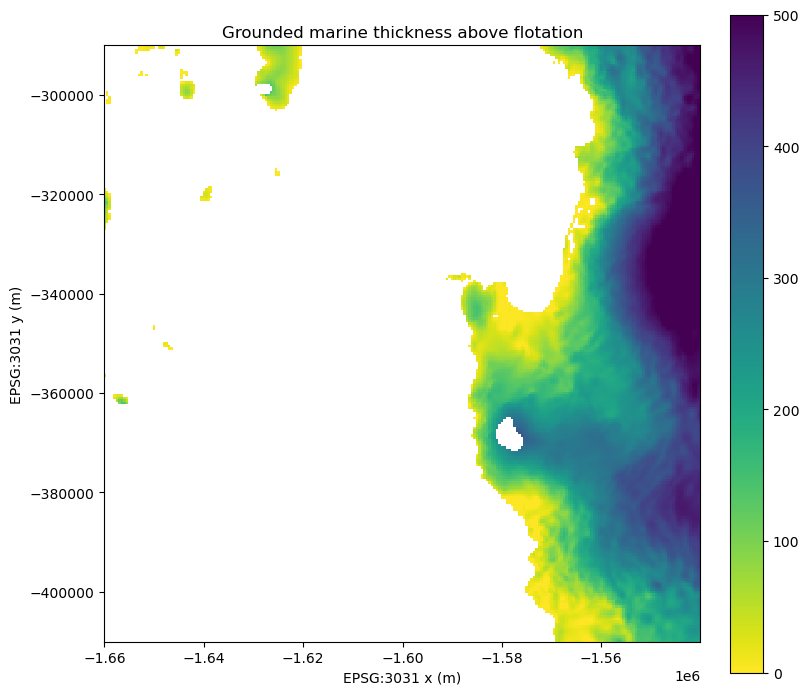

In [9]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
taf_for_plot.plot(ax=ax, cmap="viridis_r", vmin=0, vmax=500, add_colorbar=True)
ax.set_title("Grounded marine thickness above flotation")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 2: Ice-Shelf Basal Melt Rate

The basal-melt workflow is available as a raster layer in the combined cube. This
plot shows the melt-rate field for the same ROI. The original shelf-name polygon
time series is not part of these raster cubes, but the gridded melt-rate field is
ready for spatial overlay and small-area statistics.


In [10]:
basal_melt = combined["ice_shelf_basal_melt_rate"]
basal_melt_mean = basal_melt.mean(skipna=True)


In [11]:
basal_melt_plot, basal_melt_mean = compute_with_progress(basal_melt, basal_melt_mean)
print(f"Mean basal melt rate in ROI: {float(basal_melt_mean.values):.3g}")


[########################################] | 100% Completed | 706.98 ms
Mean basal melt rate in ROI: 7.77


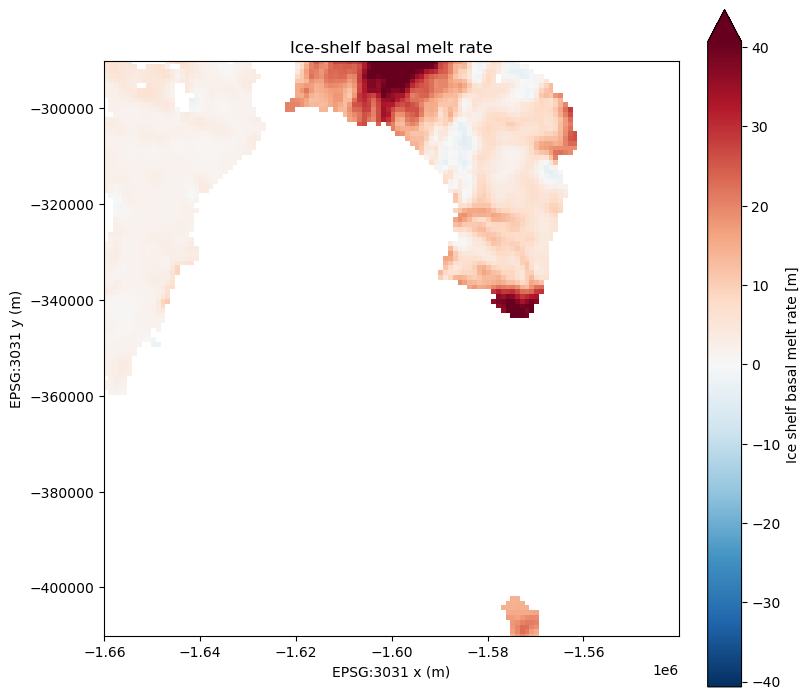

In [12]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
basal_melt_plot.plot(ax=ax, cmap="RdBu_r", robust=True, add_colorbar=True)
ax.set_title("Ice-shelf basal melt rate")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 3: Surface Elevation Change

The SEC cube stores gridded surface-elevation-change rates by time period. This
example takes the latest period, masks to grounded ice, converts metres to
millimetres, and plots the spatial fingerprint of elevation gain or loss.


In [13]:
sec_period_index = -1
sec_rate = sec["surface_elevation_change_rate"].isel(time_period=sec_period_index)
sec_uncertainty = sec["surface_elevation_change_rate_uncertainty"].isel(time_period=sec_period_index)
sec_grounded_mask = sec["surface_elevation_change_surface_type"] == 2

sec_rate_mm_yr = sec_rate.where(sec_grounded_mask) * 1000.0
sec_uncertainty_mm_yr = sec_uncertainty.where(sec_grounded_mask) * 1000.0
sec_signal_to_noise = abs(sec_rate_mm_yr) / sec_uncertainty_mm_yr

sec_mean = sec_rate_mm_yr.mean(skipna=True)
sec_snr_mean = sec_signal_to_noise.mean(skipna=True)


In [14]:
sec_rate_plot, sec_mean, sec_snr_mean = compute_with_progress(sec_rate_mm_yr, sec_mean, sec_snr_mean)
print(f"Mean SEC in ROI: {float(sec_mean.values):.3g} mm/yr")
print(f"Mean SEC signal-to-noise in ROI: {float(sec_snr_mean.values):.3g}")


[########################################] | 100% Completed | 808.89 ms
Mean SEC in ROI: -798 mm/yr
Mean SEC signal-to-noise in ROI: 1.81


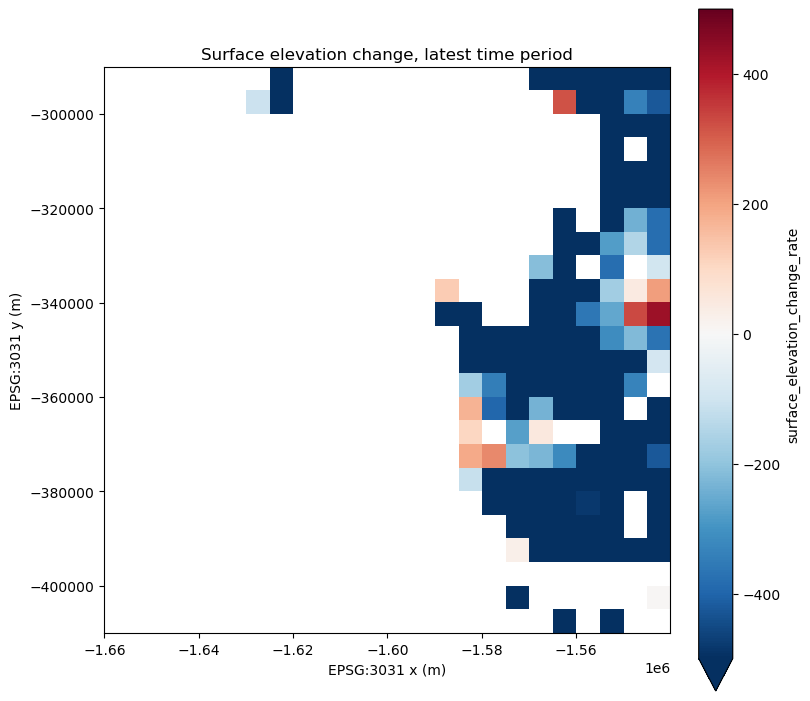

In [15]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
sec_rate_plot.plot(ax=ax, cmap="RdBu_r", vmin=-500, vmax=500, add_colorbar=True)
ax.set_title("Surface elevation change, latest time period")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 4: Englacial Temperature At A Selected Depth

The old temperature notebook reprojected a non-regular source product. In the
remote cube, ice temperature is already on the shared EPSG:3031 grid. This plot
selects the depth nearest `TEMPERATURE_DEPTH_TARGET_M` and converts Kelvin to
Celsius for display.


In [16]:
temperature_depth_index = nearest_index(icetemp["depth"], TEMPERATURE_DEPTH_TARGET_M)
temperature_depth_m = float(icetemp["depth"].isel(depth=temperature_depth_index).values)

ice_temp_k = icetemp["englacial_temp_profile_tice"].isel(depth=temperature_depth_index)
ice_temp_c = ice_temp_k - 273.15
ice_temp_c.attrs.update(long_name="Ice temperature", units="degC")
ice_temp_mean = ice_temp_c.mean(skipna=True)


In [17]:
ice_temp_plot, ice_temp_mean = compute_with_progress(ice_temp_c, ice_temp_mean)
print(f"Selected depth: {temperature_depth_m:g} m")
print(f"Mean ice temperature in ROI: {float(ice_temp_mean.values):.3g} degC")


[########################################] | 100% Completed | 303.81 ms
Selected depth: 1000 m
Mean ice temperature in ROI: nan degC


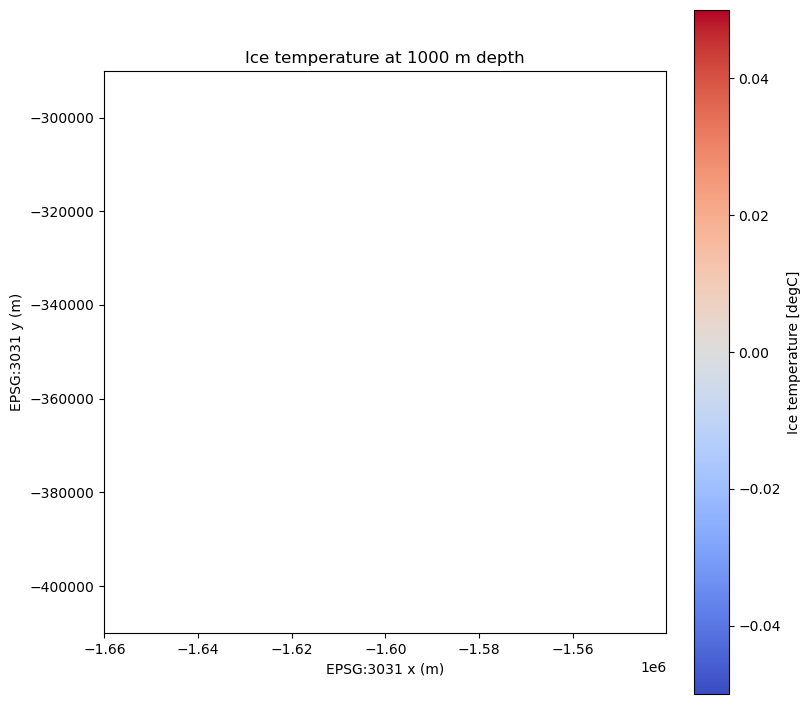

In [18]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
ice_temp_plot.plot(ax=ax, cmap="coolwarm", robust=True, add_colorbar=True)
ax.set_title(f"Ice temperature at {temperature_depth_m:g} m depth")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 5: Calving-Front Mask Change

The calving-front product is transformed from time-evolving vector polygons into
a raster mask stack. This plot compares the first and last available masks in
the ROI, highlighting where the binary mask changed through time.


In [19]:
calving_first = calving["calving_fronts"].isel(time=0)
calving_last = calving["calving_fronts"].isel(time=-1)
calving_change = calving_last - calving_first

calving_first_time = scalar_label(calving["time"].isel(time=0).values)
calving_last_time = scalar_label(calving["time"].isel(time=-1).values)
calving_changed_cells = (calving_change != 0).sum()


In [20]:
calving_change_plot, calving_changed_cells = compute_with_progress(calving_change, calving_changed_cells)
print(f"Calving-front mask comparison: {calving_first_time} to {calving_last_time}")
print(f"Changed cells in ROI: {int(calving_changed_cells.values):,}")


[########################################] | 100% Completed | 808.49 ms
Calving-front mask comparison: 1997-10-01 to 2021-03-15
Changed cells in ROI: 132,432


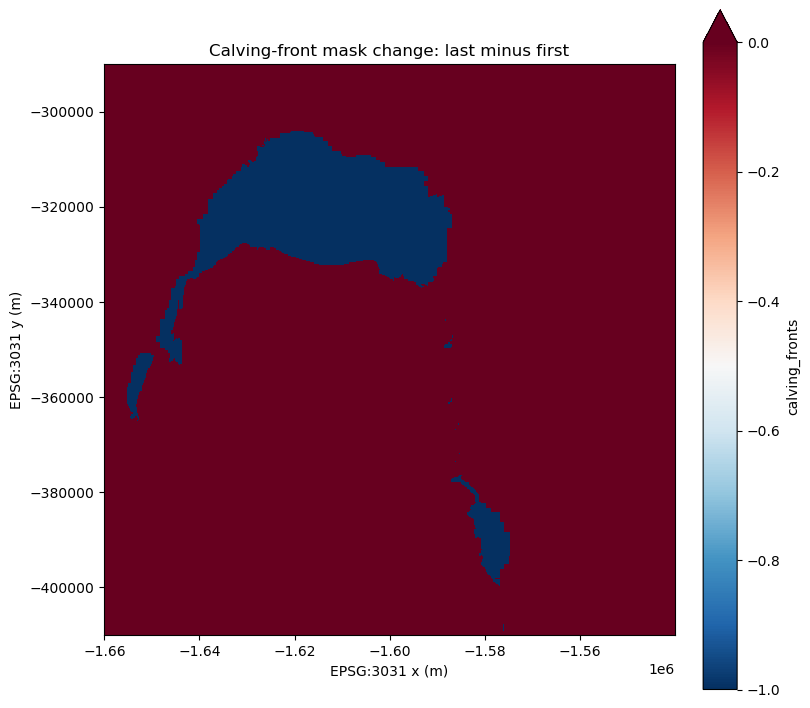

In [21]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
calving_change_plot.plot(ax=ax, cmap="RdBu_r", robust=True, add_colorbar=True)
ax.set_title("Calving-front mask change: last minus first")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 6: Grounding Lines And Lake Masks

The groundline, subglacial-lake, and supraglacial-lake workflows are available
as raster masks in the combined cube. This plot combines them into one class-code
image for a compact overview: `1` marks supraglacial lakes/channels, `2` marks
subglacial lakes, and `4` marks grounding-line pixels. Sums indicate overlap.


In [22]:
supraglacial_lake_mask = combined["supra_glacial_lakes_mask"] > 0
subglacial_lake_mask = combined["subglacial_lakes_mask"] > 0
grounding_line_mask = combined["groundlines_mask"] > 0

hydrology_grounding_code = (
    supraglacial_lake_mask.astype("uint8")
    + 2 * subglacial_lake_mask.astype("uint8")
    + 4 * grounding_line_mask.astype("uint8")
)

supraglacial_cells = supraglacial_lake_mask.sum()
subglacial_cells = subglacial_lake_mask.sum()
grounding_line_cells = grounding_line_mask.sum()


In [23]:
(
    hydrology_grounding_plot,
    supraglacial_cells,
    subglacial_cells,
    grounding_line_cells,
) = compute_with_progress(
    hydrology_grounding_code,
    supraglacial_cells,
    subglacial_cells,
    grounding_line_cells,
)

print(f"Supraglacial lake/channel cells: {int(supraglacial_cells.values):,}")
print(f"Subglacial lake cells: {int(subglacial_cells.values):,}")
print(f"Grounding-line cells: {int(grounding_line_cells.values):,}")


[########################################] | 100% Completed | 303.21 ms
Supraglacial lake/channel cells: 0
Subglacial lake cells: 0
Grounding-line cells: 9,629


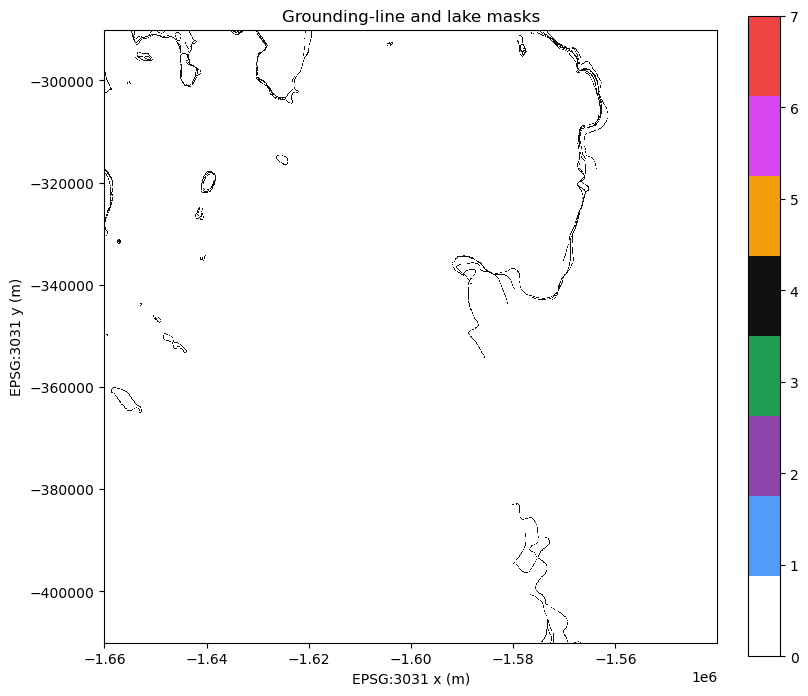

In [24]:
mask_cmap = ListedColormap([
    "white",
    "#4f9cf9",
    "#8e44ad",
    "#1f9d55",
    "#111111",
    "#f59e0b",
    "#d946ef",
    "#ef4444",
])

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
hydrology_grounding_plot.plot(ax=ax, cmap=mask_cmap, vmin=0, vmax=7, add_colorbar=True)
ax.set_title("Grounding-line and lake masks")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()


## Plot 7: Ice Velocity Vectors Over Basal Melt

The velocity cube provides easting, northing, and magnitude variables on the same
remote grid. This section samples the latest time step coarsely for arrows and
plots those vectors over the basal-melt raster computed earlier.


In [25]:
velocity_latest = velocity[
    [
        "ice_sheet_surface_velocity_easting",
        "ice_sheet_surface_velocity_northing",
        "ice_sheet_surface_velocity_magnitude",
    ]
].isel(time=-1)

velocity_sample = velocity_latest.isel(
    y=slice(None, None, VELOCITY_VECTOR_STRIDE),
    x=slice(None, None, VELOCITY_VECTOR_STRIDE),
)
velocity_time = scalar_label(velocity["time"].isel(time=-1).values)
velocity_mean = velocity_latest["ice_sheet_surface_velocity_magnitude"].mean(skipna=True)


In [26]:
velocity_sample_plot, velocity_mean = compute_with_progress(velocity_sample, velocity_mean)
print(f"Velocity time step: {velocity_time}")
print(f"Mean velocity magnitude in ROI: {float(velocity_mean.values):.3g}")


[########################################] | 100% Completed | 11.59 ss
Velocity time step: 2021-12-01
Mean velocity magnitude in ROI: 1.73


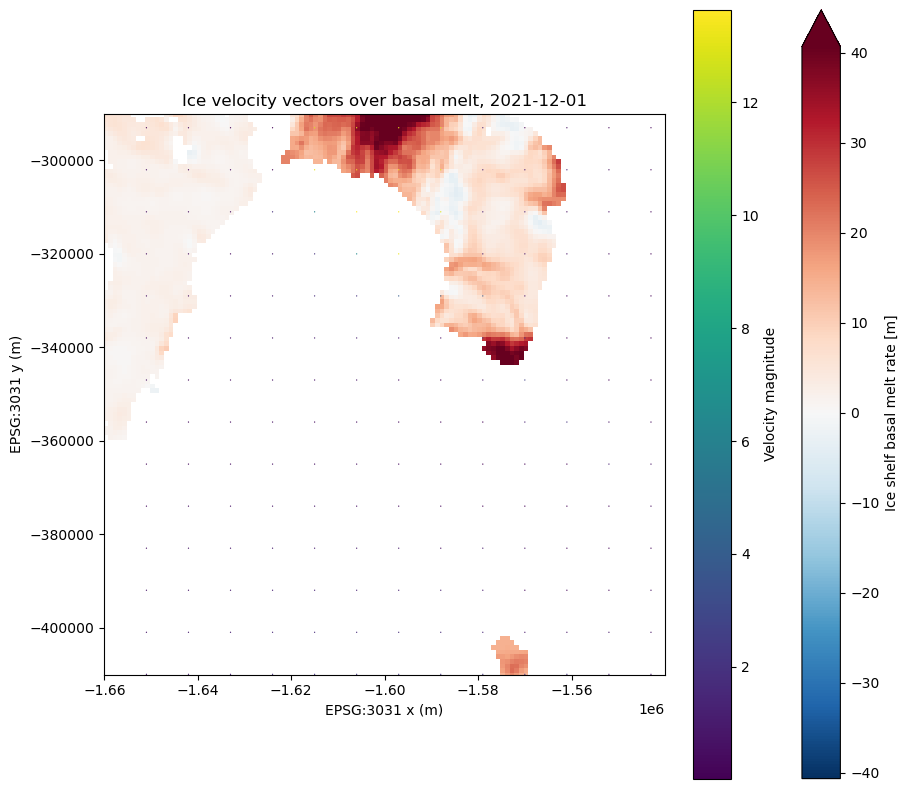

In [27]:
u = velocity_sample_plot["ice_sheet_surface_velocity_easting"]
v = velocity_sample_plot["ice_sheet_surface_velocity_northing"]
speed = velocity_sample_plot["ice_sheet_surface_velocity_magnitude"]

x_m = velocity_sample_plot["x"].values
y_m = velocity_sample_plot["y"].values
X, Y = np.meshgrid(x_m, y_m)

finite_speed = speed.values[np.isfinite(speed.values)]
quiver_scale = float(np.nanpercentile(finite_speed, 95) * 25) if finite_speed.size else 2.0

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
basal_melt_plot.plot(ax=ax, cmap="RdBu_r", robust=True, add_colorbar=True)
q = ax.quiver(
    X,
    Y,
    u.values,
    v.values,
    speed.values,
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=quiver_scale,
    width=0.0025,
)
fig.colorbar(q, ax=ax, label="Velocity magnitude")
ax.set_title(f"Ice velocity vectors over basal melt, {velocity_time}")
ax.set_xlabel("EPSG:3031 x (m)")
ax.set_ylabel("EPSG:3031 y (m)")
ax.set_aspect("equal")
plt.show()
